In [45]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

In [46]:
df = pd.read_csv("healthcare_dataset.csv")
df_backup = df.copy()
df_backup.to_csv("healthcare_backup",index=False)

In [47]:
pd.set_option('future.no_silent_downcasting', True)

In [48]:
print(df.shape) # number of rows & columns

(55500, 15)


In [49]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [50]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [51]:
print(df.isnull().sum()) # لايجاد القيم الفارغة

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64


In [52]:
df.duplicated().sum()

np.int64(534)

In [53]:
df.drop_duplicates(inplace=True)

In [54]:
print("number of rows after deleting duplicate rows = ",len(df))

number of rows after deleting duplicate rows =  54966


In [55]:
df.duplicated().sum() # حساب عدد الصفوف المكررة

np.int64(0)

In [56]:
print(df["Gender"].value_counts())
print(df["Blood Type"].value_counts())

Gender
Male      27496
Female    27470
Name: count, dtype: int64
Blood Type
A-     6898
A+     6896
B+     6885
AB+    6882
AB-    6874
B-     6872
O+     6855
O-     6804
Name: count, dtype: int64


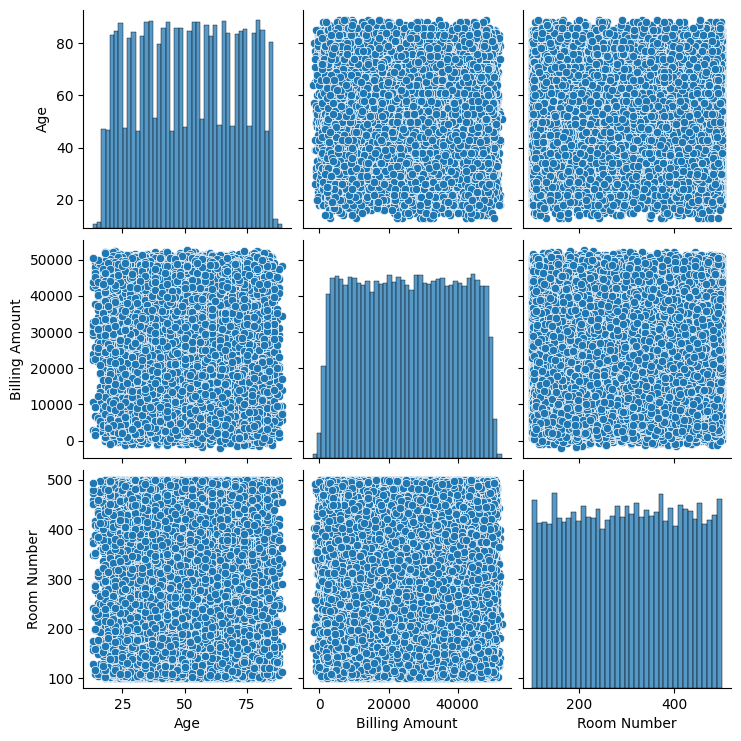

In [57]:
sns.pairplot(df)
plt.show()

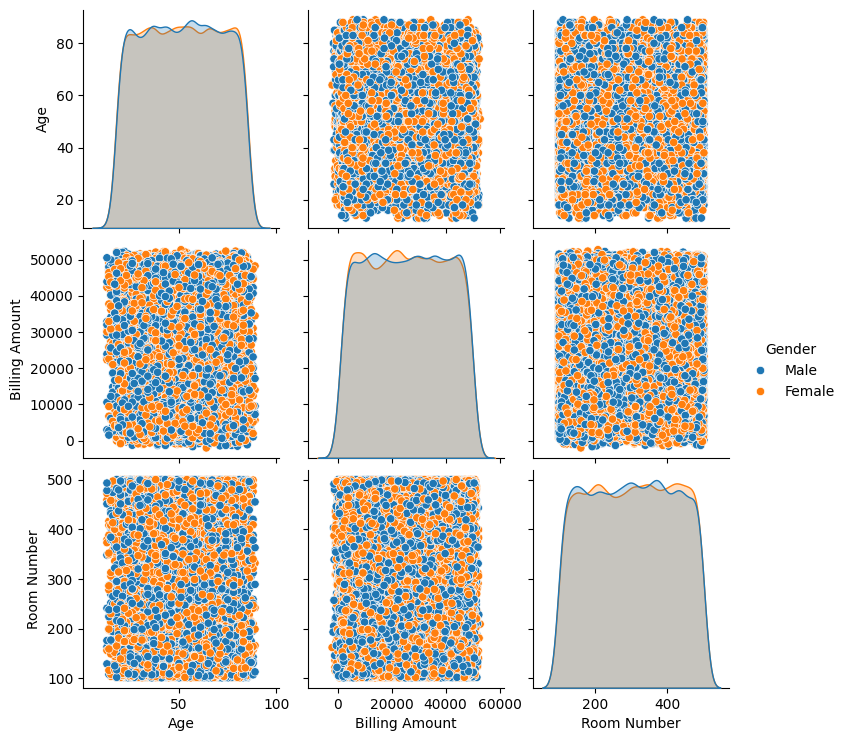

In [58]:
sns.pairplot(df,hue='Gender')
plt.show()

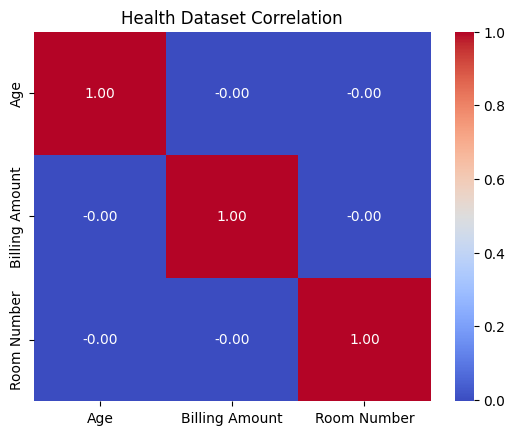

In [59]:
# حساب مصفوفة الارتباط
correlation = df.corr(numeric_only=True)

# رسم خريطة الارتباط
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Health Dataset Correlation")
plt.show()

In [60]:
df.drop(columns=['Name','Doctor','Hospital',], inplace=True) # Delete all columns whose type is not number 

In [61]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission']) # Convert date in Date of Admission to int
df['Date_of_admission'] = (df['Date of Admission'] - pd.Timestamp('2000-01-01')).dt.days
df.drop(columns=['Date of Admission'], inplace=True)

In [62]:
df['Discharge Date'] = pd.to_datetime(df['Discharge Date']) # Convert date in Discharge Date to int
df['Discharge_Date'] = (df['Discharge Date'] - pd.Timestamp('2000-01-01')).dt.days
df.drop(columns=['Discharge Date'], inplace=True)

In [63]:
print(df.columns)

Index(['Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type',
       'Medication', 'Test Results', 'Date_of_admission', 'Discharge_Date'],
      dtype='object')


In [64]:
from sklearn.preprocessing import LabelEncoder
gender = LabelEncoder()
df["Gender"] = gender.fit_transform(df["Gender"])
print("Gender")
for i,val in enumerate(gender.classes_):
    print(f"'{val}'mapped to {i}")

Gender
'Female'mapped to 0
'Male'mapped to 1


In [65]:
blood_type = LabelEncoder()
df["Blood Type"] = blood_type.fit_transform(df["Blood Type"])
print("Blood Type")
for i,val in enumerate(blood_type.classes_):
    print(f"'{val}'mapped to {i}")

Blood Type
'A+'mapped to 0
'A-'mapped to 1
'AB+'mapped to 2
'AB-'mapped to 3
'B+'mapped to 4
'B-'mapped to 5
'O+'mapped to 6
'O-'mapped to 7


In [66]:
medical_condition = LabelEncoder()
df["Medical Condition"] = medical_condition.fit_transform(df["Medical Condition"])
print("Medical Condition")
for i,val in enumerate(medical_condition.classes_):
    print(f"'{val}'mapped to {i}")

Medical Condition
'Arthritis'mapped to 0
'Asthma'mapped to 1
'Cancer'mapped to 2
'Diabetes'mapped to 3
'Hypertension'mapped to 4
'Obesity'mapped to 5


In [67]:
insurance = LabelEncoder()
df["Insurance Provider"] = insurance.fit_transform(df["Insurance Provider"])
print("Insurance Provider")
for i,val in enumerate(insurance.classes_):
    print(f"'{val}'mapped to {i}")

Insurance Provider
'Aetna'mapped to 0
'Blue Cross'mapped to 1
'Cigna'mapped to 2
'Medicare'mapped to 3
'UnitedHealthcare'mapped to 4


In [68]:
admission_type = LabelEncoder()
df["Admission Type"] = admission_type.fit_transform(df["Admission Type"])
print("Admission Type")
for i,val in enumerate(admission_type.classes_):
    print(f"'{val}'mapped to {i}")

Admission Type
'Elective'mapped to 0
'Emergency'mapped to 1
'Urgent'mapped to 2


In [69]:
medication = LabelEncoder()
df["Medication"] = medication.fit_transform(df["Medication"])
print("Medication")
for i,val in enumerate(medication.classes_):
    print(f"'{val}'mapped to {i}")

Medication
'Aspirin'mapped to 0
'Ibuprofen'mapped to 1
'Lipitor'mapped to 2
'Paracetamol'mapped to 3
'Penicillin'mapped to 4


In [70]:
test_results = LabelEncoder()
df["Test Results"] = test_results.fit_transform(df["Test Results"])
print("Test Results")
for i,val in enumerate(test_results.classes_):
    print(f"'{val}'mapped to {i}")

Test Results
'Abnormal'mapped to 0
'Inconclusive'mapped to 1
'Normal'mapped to 2


In [71]:
print(df.dtypes)

Age                     int64
Gender                  int64
Blood Type              int64
Medical Condition       int64
Insurance Provider      int64
Billing Amount        float64
Room Number             int64
Admission Type          int64
Medication              int64
Test Results            int64
Date_of_admission       int64
Discharge_Date          int64
dtype: object


In [72]:
X = df.drop("Medical Condition",axis=1) # featuers : المميزات
y = df["Medical Condition"] # Target : الهدف

In [73]:
print(df["Medical Condition"].value_counts())
print(df["Medical Condition"].value_counts(normalize=True))  # النسبة المئوية

Medical Condition
0    9218
3    9216
4    9151
5    9146
2    9140
1    9095
Name: count, dtype: int64
Medical Condition
0    0.167704
3    0.167667
4    0.166485
5    0.166394
2    0.166285
1    0.165466
Name: proportion, dtype: float64


In [74]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,random_state=42
)

In [75]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [76]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
# Algorithm Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=10) # انشاء النموذج *اقرب 10 اشخاص
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test) # التنبؤ على بيانات الاختبار
accuracy = accuracy_score(y_test, y_pred) # حساب الدقة
correct_predictions = (y_pred == y_test).sum()
print("Number of correct predictions:", correct_predictions)

print("Accuracy:", accuracy)

Number of correct predictions: 2109
Accuracy: 0.19183190831362562


In [77]:
X = X_train[:100]
y = y_train[:100]
from sklearn.svm import SVC# Algorithm RBF SVM
from sklearn.metrics import  accuracy_score
svm_rbf = SVC(kernel="rbf")
svm_rbf.fit(X,y)
y_pred_svm_rbf = svm_rbf.predict(X_test)
acc_svm_rbf = accuracy_score(y_test,y_pred_svm_rbf)
correct_predictions = (y_pred_svm_rbf == y_test).sum()
print("Number of correct predictions:", correct_predictions)
print("Accuracy_svm = " ,acc_svm_rbf)

Number of correct predictions: 1811
Accuracy_svm =  0.16472621429870837


In [78]:
X = X_train[:100]
y = y_train[:100]
from sklearn.gaussian_process import GaussianProcessClassifier #Algorithm Gaussian Process
gp = GaussianProcessClassifier()
gp.fit(X,y)
y_pred_gp = gp.predict(X_test)
acc_gp = accuracy_score(y_test,y_pred_gp)
correct_predictions = (y_pred_gp == y_test).sum()
print("Number of correct predictions:", correct_predictions)
print("Accuracy_gp = ",acc_gp)

Number of correct predictions: 1832
Accuracy_gp =  0.16663634709841732


In [79]:
from sklearn.tree import DecisionTreeClassifier # Algorithm Decision Tree
from sklearn.metrics import  accuracy_score
tree = DecisionTreeClassifier()
tree.fit(X_train,y_train)
y_pred_tree = tree.predict(X_test)
acc_tree = (y_test,y_pred_tree)
correct_predictions = (y_pred_tree == y_test).sum()
print("Number of correct predictions:", correct_predictions)
print("Accuracy_Tree = ",acc_tree)

Number of correct predictions: 2901
Accuracy_Tree =  (47632    5
28105    1
22395    5
47673    0
54827    4
        ..
39634    5
10533    1
22996    5
17005    5
27101    5
Name: Medical Condition, Length: 10994, dtype: int64, array([5, 5, 1, ..., 2, 1, 5], shape=(10994,)))


In [80]:
from sklearn.ensemble import RandomForestClassifier # Algorithm Random Forest
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = (y_test,y_pred_rf)
correct_predictions = (y_pred_rf == y_test).sum()
print("Number of correct predictions:", correct_predictions)
print("Accuracy_RF = ",acc_rf)

Number of correct predictions: 3185
Accuracy_RF =  (47632    5
28105    1
22395    5
47673    0
54827    4
        ..
39634    5
10533    1
22996    5
17005    5
27101    5
Name: Medical Condition, Length: 10994, dtype: int64, array([1, 2, 2, ..., 3, 1, 5], shape=(10994,)))


In [81]:
from sklearn.neural_network import MLPClassifier # Algorithm Neural Net
nn = MLPClassifier(max_iter=500) # اقصى عدد لللفات او التكرارات يمر فيها النموذج للتعلم
nn.fit(X_train,y_train)
y_pred_nn = nn.predict(X_test)
acc_nn = (y_test,y_pred_nn)
correct_predictions = (y_pred_nn == y_test).sum()
print("Number of correct predictions:", correct_predictions)
print("Accuracy_nn = ",acc_nn)

Number of correct predictions: 1758
Accuracy_nn =  (47632    5
28105    1
22395    5
47673    0
54827    4
        ..
39634    5
10533    1
22996    5
17005    5
27101    5
Name: Medical Condition, Length: 10994, dtype: int64, array([4, 4, 4, ..., 4, 4, 4], shape=(10994,)))


In [82]:
from sklearn.ensemble import AdaBoostClassifier # Algorithm AdaBoost
ada = AdaBoostClassifier()
ada.fit(X_train,y_train)
y_pred_ada = ada.predict(X_test)
acc_ada = (y_test,y_pred_ada)
correct_predictions = (y_pred_ada == y_test).sum()
print("Number of correct predictions:", correct_predictions)
print("Accuracy_ada = ",acc_ada)

Number of correct predictions: 1759
Accuracy_ada =  (47632    5
28105    1
22395    5
47673    0
54827    4
        ..
39634    5
10533    1
22996    5
17005    5
27101    5
Name: Medical Condition, Length: 10994, dtype: int64, array([4, 4, 4, ..., 4, 4, 4], shape=(10994,)))


In [83]:
from sklearn.naive_bayes import GaussianNB # Algorithm Naive Bayes
nb = GaussianNB()
nb.fit(X_train,y_train)
y_pred_nb = nb.predict(X_test)
acc_nb = (y_test,y_pred_nb)
correct_predictions = (y_pred_nb == y_test).sum()
print("Number of correct predictions:", correct_predictions)
print("Accuracy_nb = ",acc_nb)

Number of correct predictions: 1830
Accuracy_nb =  (47632    5
28105    1
22395    5
47673    0
54827    4
        ..
39634    5
10533    1
22996    5
17005    5
27101    5
Name: Medical Condition, Length: 10994, dtype: int64, array([3, 0, 1, ..., 3, 1, 3], shape=(10994,)))
